In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# !pip install nlpaug
# import nltk
# nltk.download('averaged_perceptron_tagger')
# nltk.download('pubmed')
# import nlpaug
# import nlpaug.augmenter.word as naw
# aug = naw.SynonymAug(aug_src='pubmed',aug_max=2)
# aug.augment("Misleading reviews. Worst coffee ever had, and sorely disappointing vibe.",n=2)

In [ ]:
!pip install sentencepiece

In [ ]:
# !pip install transformers=='4.2.0'
!pip install transformers

In [ ]:
import numpy as np # used for handling numbers
import pandas as pd # used for handling the dataset
from sklearn.impute import SimpleImputer # used for handling missing data
from sklearn.preprocessing import LabelEncoder, OneHotEncoder # used for encoding categorical data
from sklearn.model_selection import train_test_split # used for splitting training and testing data
from sklearn.preprocessing import StandardScaler # used for feature scaling

In [ ]:
import pandas as pd
train=pd.read_csv('/content/drive/MyDrive/Major_Project/Codebase/training/labeled_preprocessed_training.csv', encoding='utf-8')

In [ ]:
# train=train.astype({"text": str})

In [ ]:
# train=train.astype(str).apply(lambda x: x.str.encode('ascii', 'ignore').str.decode('ascii'))
# train

In [ ]:
# import nltk
# nltk.download('stopwords')
# from nltk.corpus import stopwords

# stop_words = stopwords.words('english')
# train['preprocessed_tweet'] = train['preprocessed_tweet'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))
# train["preprocessed_tweet"] = train['preprocessed_tweet'].str.replace('[^\w\s]','')

In [ ]:
# train=train.iloc[:,0:]
train.head()

,id,text,source,label,cleaned_text_1,cleaned_text_2
0,1,at 50 votes i will close this survey and take ...,twitter,0,50 votes close survey take new photos,at 50 votes i will close this survey and take ...
1,2,"21st birthday and nearly 4 months pregnant, no...",twitter,1,21st birthday nearly 4 months pregnant,21st birthday and nearly 4 months pregnant no
2,3,@_DudeThePie // I'd be killed. He's literally ...,twitter,0,killed literally 10th picture https,i be killed he literally my 10th picture https
3,4,"This year I'm gonna become a mum and turn 20, ...",twitter,1,year gon na become mum turn 20 waaaaah,this year i gon na become a mum and turn 20 wa...
4,5,Don't mind me. Just freaking out because Mary-...,twitter,0,mind freaking ashley olsen turned https,do mind me just freaking out because and ashle...


<Axes: ylabel='label'>

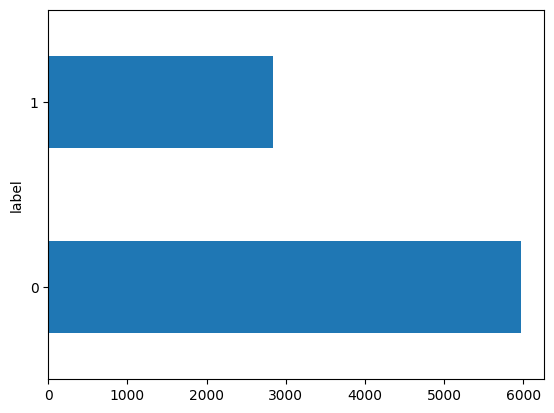

In [ ]:
train['label'].value_counts().plot(kind="barh")

In [ ]:
train.isnull().sum().sum()

0

In [ ]:
train = train.sample(frac = 1)

In [ ]:
# '''new_train=train.iloc[:7000,:]
# test=train.iloc[7000:,:]
# train=new_train'''

In [ ]:
# new_zero = pd.DataFrame(aug_text,columns=['text'])
# new_zero['status']=status_zero

In [ ]:
# import nltk
# nltk.download('pubmed')
# import nlpaug.augmenter.word as naw
# aug = naw.SynonymAug(aug_src='pubmed',aug_max=5)
# aug_text=[]
# status_zero=[]
# for i in x:
#   a=aug.augment(i,n=4)
#   for j in a:
#     aug_text.append(j)
#     status_zero.append(0)
#   aug_text.append(i)
#   status_zero.append(0)

In [ ]:
import transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification,AutoModel

# tokenizer = AutoTokenizer.from_pretrained("nghuyong/ernie-2.0-en")

# model = AutoModelForSequenceClassification.from_pretrained("nghuyong/ernie-2.0-en",output_hidden_states=True,num_labels=7)

tokenizer = transformers.AutoTokenizer.from_pretrained('bert-large-uncased')


model = AutoModelForSequenceClassification.from_pretrained('bert-large-uncased')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-large-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
train.label.unique()

array([1, 0])

In [ ]:
# labels={'Non_hope_speech': 0,
#  'Hope_speech': 1,}
# # train['uid']= train['uid'].map(labels)
# # labels={'OAG':    0,
# #  'CAG': 1,
# #  'NAG': 2}
# # labels={'GEN': 0,
# # #  'NGEN': 1}
# # labels={'0': 0,
# #  '1': 1}
# train['category']= train['category'].map(labels)


In [ ]:
len(train.label.unique())


2

In [ ]:
sentences = train.cleaned_text_2.values
labels = train.label.values
print(len(sentences), len(labels))

8800 8800


In [ ]:
# token_counts = []
# for _, row in train.iterrows():
#   token_count = len(tokenizer.encode(
#     row["preprocessed_tweet"],
#     max_length=200,
#     truncation=True
#   ))
#   token_counts.append(token_count)
# sns.histplot(token_counts)
# plt.xlim([0, 200])

In [ ]:
import tqdm as tqdm
import torch

In [ ]:
res = max(train['cleaned_text_2'], key = len)
len(res)
res = sum(map(len, train['cleaned_text_2']))/float(len(train['cleaned_text_2']))
c=0
for i in train['cleaned_text_2']:
    if len(i)<100:
        c=c+1
c

5440

In [ ]:
# Tokenize all of the sentences and map the tokens to thier word IDs.
input_ids = []
attention_masks = []

# For every sentence...
for sent in tqdm.tqdm(sentences):
    # `encode_plus` will:
    #   (1) Tokenize the sentence.
    #   (2) Prepend the `[CLS]` token to the start.
    #   (3) Append the `[SEP]` token to the end.
    #   (4) Map tokens to their IDs.
    #   (5) Pad or truncate the sentence to `max_length`
    #   (6) Create attention masks for [PAD] tokens.
    encoded_dict = tokenizer.encode_plus(
                        sent,                      # Sentence to encode.
                        add_special_tokens = True, # Add '[CLS]' and '[SEP]'
                        max_length =200 ,           # Pad & truncate all sentences.
                        pad_to_max_length = True,
                        return_attention_mask = True,   # Construct attn. masks.
                        return_tensors = 'pt',     # Return pytorch tensors.
                        truncation=True
                   )

    # Add the encoded sentence to the list.
    input_ids.append(encoded_dict['input_ids'])

    # And its attention mask (simply differentiates padding from non-padding).
    attention_masks.append(encoded_dict['attention_mask'])

# Convert the lists into tensors.
input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)
labels = torch.tensor(labels)

# Print sentence 0, now as a list of IDs.
print('Original: ', sentences[0])
print('Token IDs:', input_ids[0])

  0%|          | 0/8800 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:2645: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(
100%|██████████| 8800/8800 [00:03<00:00, 2741.40it/s]

Original:  dealing with engineering is stressful as fuck i a 21 year old tech that is now the lead of a project and 5 other techs wtf
Token IDs: tensor([  101,  7149,  2007,  3330,  2003,  6911,  3993,  2004,  6616,  1045,
         1037,  2538,  2095,  2214,  6627,  2008,  2003,  2085,  1996,  2599,
         1997,  1037,  2622,  1998,  1019,  2060,  6627,  2015,  1059, 24475,
          102,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     

In [ ]:
labels.unique()

tensor([0, 1])

In [ ]:
from torch.utils.data import TensorDataset, random_split

# Combine the training inputs into a TensorDataset.
dataset = TensorDataset(input_ids, attention_masks, labels)

# Create a 90-10 train-validation "split.

# Calculate the number of samples to include in each set.
train_size = int(len(dataset))
# val_size = len(dataset) - train_size

# Divide the dataset by randomly selecting samples.
# train_dataset = random_split(dataset, [train_size])
print('{:>5,} training samples'.format(train_size))
# print('{:>5,} validation samples'.format(val_size))

8,800 training samples


In [ ]:
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler

# The DataLoader needs to know our batch size for training, so we specify it
# here. For fine-tuning BERT on a specific task, the authors recommend a batch
# size of 16 or 32.
batch_size = 8
# Create the DataLoaders for our training and validation sets.
# We'll take training samples in random order.
train_dataloader = DataLoader(
            dataset,  # The training samples.
            # sampler = RandomSampler(train_dataset), # Select batches randomly
            batch_size = batch_size # Trains with this batch size.
        )

In [ ]:
from transformers import AdamW
optimizer = AdamW(model.parameters(),
                  lr = 1e-5, # args.learning_rate - default is 5e-5, our notebook had 2e-5
                  eps = 1e-8 # args.adam_epsilon  - default is 1e-8.
                )

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:429: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [ ]:
from transformers import get_linear_schedule_with_warmup

# Number of training epochs. The BERT authors recommend between 2 and 4.
# We chose to run for 4, but we'll see later that this may be over-fitting the
# training data.
epochs = 5
# Total number of training steps is [number of batches] x [number of epochs].
# (Note that this is not the same as the number of training samples).
total_steps = len(train_dataloader) * epochs

# Create the learning rate scheduler.
scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps = 0, # Default value in run_glue.py
                                            num_training_steps = total_steps)

In [ ]:
import numpy as np

# Function to calculate the accuracy of our predictions vs labels
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

In [ ]:
import torch

# If there's a GPU available...
if torch.cuda.is_available():

    # Tell PyTorch to use the GPU.
    device = torch.device("cuda")

    print('There are %d GPU(s) available.' % torch.cuda.device_count())

    print('We will use the GPU:', torch.cuda.get_device_name(0))

# If not...
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

There are 1 GPU(s) available.
We will use the GPU: Tesla T4


In [ ]:
import datetime
torch.cuda.empty_cache()

In [ ]:
model.cuda()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 1024, padding_idx=0)
      (position_embeddings): Embedding(512, 1024)
      (token_type_embeddings): Embedding(2, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-23): 24 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (LayerNorm): LayerNorm((1024,

In [ ]:
import os

# Saving best-practices: if you use defaults names for the model, you can reload it using from_pretrained()

output_dir = '/content/drive/MyDrive/bert-base'

# Create output directory if needed
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print("Saving model to %s" % output_dir)

Saving model to /content/drive/MyDrive/bert-base


In [ ]:
import random
import numpy as np
import time
# This training code is based on the `run_glue.py` script here:
# https://github.com/huggingface/transformers/blob/5bfcd0485ece086ebcbed2d008813037968a9e58/examples/run_glue.py#L128

# Set the seed value all over the place to make this reproducible.
seed_val = 42

random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

# We'll store a number of quantities such as training and validation loss,
# validation accuracy, and timings.
training_stats = []

# Measure the total training time for the whole run.
total_t0 = time.time()

# For each epoch...
for epoch_i in range(0, epochs):

    # ========================================
    #               Training
    # ========================================

    # Perform one full pass over the training set.

    print("")
    print('======== Epoch {:} / {:} ========'.format(epoch_i + 1, epochs))
    print('Training...')

    # Measure how long the training epoch takes.
    t0 = time.time()

    # Reset the total loss for this epoch.
    total_train_loss = 0
    total_eval_accuracy=0

    # Put the model into training mode. Don't be mislead--the call to
    # `train` just changes the *mode*, it doesn't *perform* the training.
    # `dropout` and `batchnorm` layers behave differently during training
    # vs. test (source: https://stackoverflow.com/questions/51433378/what-does-model-train-do-in-pytorch)
    model.train()

    # For each batch of training data...
    for step, batch in enumerate(train_dataloader):

        # Progress update every 40 batches.
        if step % 1000 == 0 and not step == 0:
            # Calculate elapsed time in minutes.
            elapsed = time.time() - t0

            # Report progress.
            print('  Batch {:>5,}  of  {:>5,}.    Elapsed: {:}.'.format(step, len(train_dataloader), elapsed))

        # Unpack this training batch from our dataloader.
        #
        # As we unpack the batch, we'll also copy each tensor to the GPU using the
        # `to` method.
        #
        # `batch` contains three pytorch tensors:
        #   [0]: input ids
        #   [1]: attention masks
        #   [2]: labels
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        # Always clear any previously calculated gradients before performing a
        # backward pass. PyTorch doesn't do this automatically because
        # accumulating the gradients is "convenient while training RNNs".
        # (source: https://stackoverflow.com/questions/48001598/why-do-we-need-to-call-zero-grad-in-pytorch)
        model.zero_grad()

        # Perform a forward pass (evaluate the model on this training batch).
        # The documentation for this `model` function is here:
        # https://huggingface.co/transformers/v2.2.0/model_doc/bert.html#transformers.BertForSequenceClassification
        # It returns different numbers of parameters depending on what arguments
        # arge given and what flags are set. For our useage here, it returns
        # the loss (because we provided labels) and the "logits"--the model
        # outputs prior to activation.
        outputs = model(b_input_ids,
                             token_type_ids=None,
                             attention_mask=b_input_mask,
                             labels=b_labels)
         # The call to `model` always returns a tuple, so we need to pull the
        # loss value out of the tuple.
        loss = outputs[0]
            # Move logits and labels to CPU
        logits = outputs[1].detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        # Accumulate the training loss over all of the batches so that we can
        # calculate the average loss at the end. `loss` is a Tensor containing a
        # single value; the `.item()` function just returns the Python value
        # from the tensor.
        total_train_loss += loss.item()
        total_eval_accuracy += flat_accuracy(logits, label_ids)
        # Perform a backward pass to calculate the gradients.
        loss.backward()

        # Clip the norm of the gradients to 1.0.
        # This is to help prevent the "exploding gradients" problem.
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Update parameters and take a step using the computed gradient.
        # The optimizer dictates the "update rule"--how the parameters are
        # modified based on their gradients, the learning rate, etc.
        optimizer.step()

        # Update the learning rate.
        scheduler.step()

    # # Calculate the average loss over all of the batches.
    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_train_accuracy = total_eval_accuracy / len(train_dataloader)
    print(avg_train_loss)
    print(avg_train_accuracy)
    # Measure how long this epoch took.
    training_time = time.time() - t0

    print("")
    # print("  Average training loss: {0:.2f}".format(avg_train_loss))
    print("  Training epcoh took: {:}".format(training_time))
    model_to_save = model.module if hasattr(model, 'module') else model  # Take care of distributed/parallel training
    model_to_save.save_pretrained(output_dir)
    tokenizer.save_pretrained(output_dir)

    # ========================================
    #               Validation
    # ========================================
    # After the completion of each training epoch, measure our performance on
    # our validation set.

    # print("")
    # print("Running Validation...")

    # t0 = time.time()

    # Put the model in evaluation mode--the dropout layers behave differently
    # during evaluation.
    # model.eval()

    # # Tracking variables
    # total_eval_accuracy = 0
    # total_eval_loss = 0
    # nb_eval_steps = 0

    # Evaluate data for one epoch
    # for batch in validation_dataloader:

    #     # Unpack this training batch from our dataloader.
    #     #
    #     # As we unpack the batch, we'll also copy each tensor to the GPU using
    #     # the `to` method.
    #     #
    #     # `batch` contains three pytorch tensors:
    #     #   [0]: input ids
    #     #   [1]: attention masks
    #     #   [2]: labels
    #     b_input_ids = batch[0].to(device)
    #     b_input_mask = batch[1].to(device)
    #     b_labels = batch[2].to(device)

    #     # Tell pytorch not to bother with constructing the compute graph during
    #     # the forward pass, since this is only needed for backprop (training).
    #     with torch.no_grad():

    #         # Forward pass, calculate logit predictions.
    #         # token_type_ids is the same as the "segment ids", which
    #         # differentiates sentence 1 and 2 in 2-sentence tasks.
    #         # The documentation for this `model` function is here:
    #         # https://huggingface.co/transformers/v2.2.0/model_doc/bert.html#transformers.BertForSequenceClassification
    #         # Get the "logits" output by the model. The "logits" are the output
    #         # values prior to applying an activation function like the softmax.
    #         (loss, logits) = model(b_input_ids,
    #                                token_type_ids=None,
    #                                attention_mask=b_input_mask,
    #                                labels=b_labels)

    #     # Accumulate the validation loss.
    #     # total_eval_loss += loss.item()

    #     # Move logits and labels to CPU
    #     logits = logits.detach().cpu().numpy()
    #     label_ids = b_labels.to('cpu').numpy()

    #     # Calculate the accuracy for this batch of test sentences, and
    #     # accumulate it over all batches.
    #     total_eval_accuracy += flat_accuracy(logits, label_ids)


    # # Report the final accuracy for this validation run.
    # avg_val_accuracy = total_eval_accuracy / len(validation_dataloader)
    # print("  Accuracy: {0:.2f}".format(avg_val_accuracy))

    # # Calculate the average loss over all of the batches.
    # avg_val_loss = total_eval_loss / len(validation_dataloader)

    # # Measure how long the validation run took.
    # validation_time = format_time(time.time() - t0)

    # print("  Validation Loss: {0:.2f}".format(avg_val_loss))
    # print("  Validation took: {:}".format(validation_time))

    # Record all statistics from this epoch.
    training_stats.append(
        {
            'epoch': epoch_i + 1,
            'Training Loss': avg_train_loss,
            # 'Valid. Loss': avg_val_loss,
            'Valid. Accur.': avg_train_accuracy,
            # 'Training Time': training_time,
            # 'Validation Time': validation_time
        }
    )

print("")
print("Training complete!")

# print("Total training took {:} (h:mm:ss)".format(time.time()-total_t0))


======== Epoch 1 / 5 ========
Training...
  Batch 1,000  of  1,100.    Elapsed: 951.276214838028.
0.3884807552858679
0.8520454545454546

  Training epcoh took: 1046.462102651596

======== Epoch 2 / 5 ========
Training...
  Batch 1,000  of  1,100.    Elapsed: 952.1555321216583.
0.23699904261315666
0.93625

  Training epcoh took: 1047.32199883461

======== Epoch 3 / 5 ========
Training...
  Batch 1,000  of  1,100.    Elapsed: 951.695520401001.
0.13399797416581846
0.9703409090909091

  Training epcoh took: 1046.9058203697205

======== Epoch 4 / 5 ========
Training...
  Batch 1,000  of  1,100.    Elapsed: 951.8850381374359.
0.06459902865753975
0.9868181818181818

  Training epcoh took: 1047.1860146522522

======== Epoch 5 / 5 ========
Training...
  Batch 1,000  of  1,100.    Elapsed: 951.9004399776459.
0.03814562841391307
0.9929545454545454

  Training epcoh took: 1047.031234741211

Training complete!


In [ ]:
test=pd.read_csv('/content/drive/MyDrive/Major_Project/Codebase/validation/labeled_preprocessed_validation.csv', encoding='utf-8')

In [ ]:
# test.columns=['text']
test.head()

,id,text,source,label,cleaned_text_1,cleaned_text_2
0,8801,Everybody developa cataracts with age. Disease...,reddit,0,everybody developa cataracts age diseases like...,everybody developa cataracts with age diseases...
1,8802,"I have not heard that before. I have ICL's, bu...",reddit,0,heard icl artisan toric irisclaw lenses sit fr...,i have not heard that before i have icl but ar...
2,8803,What does your doctor/fitter say? I sure wish ...,reddit,0,say sure wish could wear sclerals 38 40 year o...,what does your say i sure wish i could wear sc...
3,8804,Dear doctor of optometrists of the internet I ...,reddit,1,dear doctor optometrists internet asking advic...,dear doctor of optometrists of the internet i ...
4,8805,"If you have sharp vision without correction, p...",reddit,0,sharp vision without correction please dont ge...,if you have sharp vision without correction pl...


In [ ]:
# test=test.astype(str).apply(lambda x: x.str.encode('ascii', 'ignore').str.decode('ascii'))
# test

In [ ]:
# labels={'Non_hope_speech': 0,
#  'Hope_speech': 1,}
# # train['uid']= train['uid'].map(labels)
# # labels={'OAG':    0,
# #  'CAG': 1,
# #  'NAG': 2}
# # labels={'GEN': 0,
# # #  'NGEN': 1}
# # labels={'0': 0,
# #  '1': 1}
# test['category']= test['category'].map(labels)


In [ ]:
# test=test.rename(columns = {'text                    ':'text'})

In [ ]:
# import nltk
# nltk.download('stopwords')
# from nltk.corpus import stopwords

# stop_words = stopwords.words('english')
# test['preprocessed_tweet'] = test['preprocessed_tweet'].apply(lambda y: ' '.join([word for word in y.split() if word not in (stop_words)]))
# test["preprocessed_tweet"] = test['preprocessed_tweet'].str.replace('[^\w\s]','')

In [ ]:
# test=test.iloc[:,1:]

In [ ]:
# test=test.rename(columns = {'text_d':'text'})

In [ ]:
test

,id,text,source,label,cleaned_text_1,cleaned_text_2
0,8801,Everybody developa cataracts with age. Disease...,reddit,0,everybody developa cataracts age diseases like...,everybody developa cataracts with age diseases...
1,8802,"I have not heard that before. I have ICL's, bu...",reddit,0,heard icl artisan toric irisclaw lenses sit fr...,i have not heard that before i have icl but ar...
2,8803,What does your doctor/fitter say? I sure wish ...,reddit,0,say sure wish could wear sclerals 38 40 year o...,what does your say i sure wish i could wear sc...
3,8804,Dear doctor of optometrists of the internet I ...,reddit,1,dear doctor optometrists internet asking advic...,dear doctor of optometrists of the internet i ...
4,8805,"If you have sharp vision without correction, p...",reddit,0,sharp vision without correction please dont ge...,if you have sharp vision without correction pl...
...,...,...,...,...,...,...
4195,12996,Why can’t people just accept no as an answer! ...,reddit,1,people accept answer cant people understand li...,why can t people just accept no as an answer w...
4196,12997,Even the thought of this terrifies me. Im 18 a...,reddit,1,even thought terrifies im 18 know ever able ta...,even the thought of this terrifies me im 18 an...
4197,12998,I don't think exposure works for me either. I ...,reddit,0,think exposure works either volunteer firefigh...,i do think exposure works for me either i was ...
4198,12999,I'm a 16 year old going into Junior year of hi...,reddit,1,16 year old going junior year high school,i a 16 year old going into junior year of high...


In [ ]:
# labels={'Non-anti-LGBT+ content': 0,
#  'Homophobic': 1,
#  'Transphobic': 2}
# # train['uid']= train['uid'].map(labels)
# # labels={'OAG':    0,
# #  'CAG': 1,
# #  'NAG': 2}
# # labels={'GEN': 0,
# # #  'NGEN': 1}
# # labels={'0': 0,
# #  '1': 1}
# test['category']= test['category'].map(labels)


In [ ]:
# test=pd.read_csv('/content/test_master_multi.csv')
# test.dropna(inplace=True)
sentences2 = test.cleaned_text_2.values

input_ids = []
attention_masks = []

for sent in tqdm.tqdm(sentences2):
    # `encode_plus` will:
    #   (1) Tokenize the sentence.
    #   (2) Prepend the `[CLS]` token to the start.
    #   (3) Append the `[SEP]` token to the end.
    #   (4) Map tokens to their IDs.
    #   (5) Pad or truncate the sentence to `max_length`
    #   (6) Create attention masks for [PAD] tokens.
    encoded_dict = tokenizer.encode_plus(
                        sent,                      # Sentence to encode.
                        add_special_tokens = True, # Add '[CLS]' and '[SEP]'
                        max_length = 200,           # Pad & truncate all sentences.
                        pad_to_max_length = True,
                        return_attention_mask = True,   # Construct attn. masks.
                        return_tensors = 'pt',     # Return pytorch tensors.
                   )

    # Add the encoded sentence to the list.
    input_ids.append(encoded_dict['input_ids'])

    # And its attention mask (simply differentiates padding from non-padding).
    attention_masks.append(encoded_dict['attention_mask'])

# Convert the lists into tensors.
input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)

  0%|          | 0/4200 [00:00<?, ?it/s]Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:2645: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(
100%|██████████| 4200/4200 [00:02<00:00, 1596.59it/s]


In [ ]:
batch_size = 64

# Create the DataLoader.
prediction_data = TensorDataset(input_ids, attention_masks)
prediction_sampler = SequentialSampler(prediction_data)
prediction_dataloader = DataLoader(prediction_data, sampler=prediction_sampler, batch_size=batch_size)

In [ ]:
# test["text"]= test["text"].astype(str)

In [ ]:
model.eval()

# Tracking variables
predictions= []

# Predict
for batch in tqdm.tqdm(prediction_dataloader):
  # Add batch to GPU
  batch = tuple(t.to(device) for t in batch)

  # Unpack the inputs from our dataloader
  b_input_ids, b_input_mask = batch

  # Telling the model not to compute or store gradients, saving memory and
  # speeding up prediction
  with torch.no_grad():
      # Forward pass, calculate logit predictions
      outputs = model(b_input_ids, token_type_ids=None,
                      attention_mask=b_input_mask)

  logits = outputs[0]

  # Move logits and labels to CPU
  logits = logits.detach().cpu().numpy()

  # Store predictions and true labels
  predictions.append(logits)

print('    DONE.')

100%|██████████| 66/66 [02:33<00:00,  2.32s/it]

    DONE.


In [ ]:
from numpy import exp
def softmax(vector):
	e = exp(vector)
	return e / e.sum()

In [ ]:
res=[]
for val in predictions:
  for m in val:
    temp=softmax(m)
    # print(temp)
    u=np.argmax(temp)
    res.append(u)

In [ ]:
r=pd.DataFrame(res)

In [ ]:
test['Labels']=res

In [ ]:
# labels={0: 'Non_hope_speech',
#  1: 'Hope_speech',}
# # train['uid']= train['uid'].map(labels)
# # labels={'OAG':    0,
# #  'CAG': 1,
# #  'NAG': 2}
# # labels={'GEN': 0,
# # #  'NGEN': 1}
# # labels={'0': 0,
# #  '1': 1}
# test['Labels']= test['Labels'].map(labels)

In [ ]:
test.to_csv('/content/drive/MyDrive/bert-base/bert_predictions.csv', index=False)

In [ ]:
# from sklearn.metrics import classification_report
# classification_report(test.category, r[0])

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(test.label,r[0],digits=4))

              precision    recall  f1-score   support

           0     0.8770    0.9138    0.8950      2435
           1     0.8737    0.8232    0.8477      1765

    accuracy                         0.8757      4200
   macro avg     0.8754    0.8685    0.8714      4200
weighted avg     0.8756    0.8757    0.8751      4200



In [ ]:
# from sklearn.metrics import roc_auc_score
# roc_auc_score(test.Label,r[0])